# 🔧 Improved Rolling Spike Detection

This notebook improves on the original approach by addressing:

- Severe class imbalance in spike detection
- Enhancing lag features and adding rolling statistics
- Making better use of XGBoost with class weighting
- Avoiding unreliable Prophet-based spike flagging
- Increasing the rolling training window


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_score, recall_score, f1_score
from sklearn.ensemble import IsolationForest
from xgboost import XGBClassifier
from prophet import Prophet

c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [3]:
# Re-define spike as a % jump and add better features
df = pd.read_parquet("../data/processed/preprocessed_prophet.parquet").sort_index()
df["target"] = (df["recommended_fee_fastestFee"].shift(-288) > 5).astype(int)

lags = [1, 3, 6, 12, 24, 48, 96, 144, 288]
for lag in lags:
    df[f"lag_{lag}"] = df["recommended_fee_fastestFee"].shift(lag)

# Add rolling window statistics (mean, std, max)
df["rolling_mean"] = df["recommended_fee_fastestFee"].rolling(12).mean()
df["rolling_std"] = df["recommended_fee_fastestFee"].rolling(12).std()
df["rolling_max"] = df["recommended_fee_fastestFee"].rolling(12).max()

# Add time-based features
df["hour"] = df.index.hour
df["dayofweek"] = df.index.dayofweek

exog_cols = [c for c in df.columns if c.startswith("mempool") or "block" in c]
df = df.dropna()


In [4]:
from sklearn.utils.class_weight import compute_class_weight
from collections import Counter

window = 288 * 3  # Use 3-day training window
horizon = 288
step = 144
features = [f"lag_{lag}" for lag in lags] + ["rolling_mean", "rolling_std", "rolling_max", "hour", "dayofweek"] + exog_cols

split_idx = int(len(df) * 0.8)
train_base = df.iloc[:split_idx]
test_rolling = df.iloc[split_idx:]

# Compute scale_pos_weight for XGBoost
counter = Counter(train_base["target"])
scale_pos_weight = counter[0] / counter[1]
print(f"Class balance (0:1) -> {counter[0]}:{counter[1]}")


Class balance (0:1) -> 4522:527


In [5]:
xgb = XGBClassifier(use_label_encoder=False, eval_metric="logloss", scale_pos_weight=scale_pos_weight)
grid = {"max_depth": [3, 5], "learning_rate": [0.05, 0.1], "n_estimators": [50, 100]}
gs = GridSearchCV(xgb, grid, cv=3)
gs.fit(train_base[features], train_base["target"])
xgb_best = gs.best_estimator_


c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:34] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:34] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:34] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:34] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters:

In [6]:
results = []

for start in range(0, len(test_rolling) - window - horizon, step):
    roll_train = test_rolling.iloc[start:start + window]
    roll_test = test_rolling.iloc[start + window:start + window + horizon]

    xgb_best.fit(roll_train[features], roll_train["target"])
    pred_xgb = xgb_best.predict(roll_test[features])

    results.append({
        "model": "XGBoost",
        "start": roll_test.index[0],
        "precision": precision_score(roll_test["target"], pred_xgb, zero_division=0),
        "recall": recall_score(roll_test["target"], pred_xgb, zero_division=0),
        "f1": f1_score(roll_test["target"], pred_xgb, zero_division=0)
    })

summary = pd.DataFrame(results)
avg = summary.groupby("model")[["precision", "recall", "f1"]].mean().reset_index()
avg


c:\Users\86166\miniforge3\envs\satcast\Lib\site-packages\xgboost\training.py:183: UserWarning: [12:29:37] WARNING: D:\bld\xgboost-split_1747336820434\work\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,model,precision,recall,f1
0,XGBoost,0.0,0.0,0.0


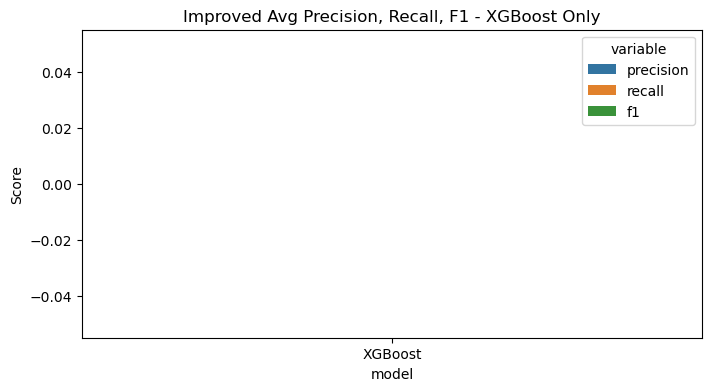

In [7]:
plt.figure(figsize=(8, 4))
sns.barplot(data=avg.melt(id_vars="model"), x="model", y="value", hue="variable")
plt.title("Improved Avg Precision, Recall, F1 - XGBoost Only")
plt.ylabel("Score")
plt.show()
